# Histograma global — valores de gris en máscaras (JPEG en bruto)

Recorre ficheros en `masks/` (como en el entrenamiento: `np.fromfile` + `cv2.imdecode` en escala de grises) y acumula un histograma **0…255** sobre **todos los píxeles**.

- Por defecto: solo `image_name` listados en `partition/` (misma lógica que `analyze_masks.py` sin `--all-masks`).
- Opcional: `USE_ALL_MASKS_IN_FOLDER = True` para usar todo lo que haya en `masks/`.
- Opcional: `MAX_MASKS` para limitar el número de máscaras (prueba rápida).

**Kernel:** entorno del proyecto con `cv2`, `matplotlib`, `pandas`.

In [1]:
from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


def find_project_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "partition").is_dir() and (p / "masks").is_dir():
            return p
    raise FileNotFoundError("No se encontró proyecto con partition/ y masks/; define BASE manualmente.")


BASE = find_project_root()
MASKS_DIR = BASE / "masks"
PARTITION = BASE / "partition"

# --- Opciones ---
USE_ALL_MASKS_IN_FOLDER = False  # True → ignora partition, usa todos los .jpg/.png en masks/
MAX_MASKS: int | None = None  # p. ej. 500 para prueba; None = sin límite

print("BASE:", BASE)
print("MASKS_DIR:", MASKS_DIR)

BASE: c:\Users\Aleix\OneDrive - Universitat Politècnica de Catalunya\Escritorio\UNI\TFG\Recerca primers datasets\SicapV2\SICAPv2
MASKS_DIR: c:\Users\Aleix\OneDrive - Universitat Politècnica de Catalunya\Escritorio\UNI\TFG\Recerca primers datasets\SicapV2\SICAPv2\masks


In [2]:
def list_partition_image_names() -> set[str]:
    patterns = (
        "Validation/*/Train.xlsx",
        "Validation/*/Test.xlsx",
        "Test/Train.xlsx",
        "Test/Test.xlsx",
    )
    names: set[str] = set()
    for pat in patterns:
        for xp in sorted(PARTITION.glob(pat)):
            df = pd.read_excel(xp)
            if "image_name" not in df.columns:
                continue
            for v in df["image_name"].dropna():
                s = str(v).strip()
                if s:
                    names.add(s)
    return names


def collect_mask_paths(*, all_masks: bool) -> list[Path]:
    if all_masks:
        paths = sorted(MASKS_DIR.glob("*.jpg")) + sorted(MASKS_DIR.glob("*.png"))
        return paths
    allowed = list_partition_image_names()
    if not allowed:
        raise RuntimeError(f"No hay image_name en {PARTITION}")
    out: list[Path] = []
    missing = 0
    for name in sorted(allowed):
        p = MASKS_DIR / name
        if p.is_file():
            out.append(p)
        else:
            missing += 1
    if missing:
        print(f"Aviso: {missing} nombres en partition sin fichero en masks/")
    return out


mask_paths = collect_mask_paths(all_masks=USE_ALL_MASKS_IN_FOLDER)
if MAX_MASKS is not None:
    mask_paths = mask_paths[: int(MAX_MASKS)]
print(f"Máscaras a leer: {len(mask_paths):,}")

Máscaras a leer: 12,081


In [3]:
def read_mask_gray(path: Path) -> np.ndarray | None:
    buf = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)


def histogram_all_pixels(paths: list[Path]) -> np.ndarray:
    """Suma de bincount 0..255 sobre todos los píxeles de todas las máscaras."""
    h = np.zeros(256, dtype=np.float64)
    n_ok = 0
    n_fail = 0
    for p in tqdm(paths, desc="Máscaras"):
        m = read_mask_gray(p)
        if m is None:
            n_fail += 1
            continue
        n_ok += 1
        bc = np.bincount(m.ravel(), minlength=256)
        h += bc.astype(np.float64)
    print(f"Leídas OK: {n_ok:,} | fallidas (imdecode None): {n_fail:,}")
    return h


hist = histogram_all_pixels(mask_paths)
total_px = float(hist.sum())
print(f"Total píxeles acumulados: {total_px:,.0f}")

Máscaras:   0%|          | 0/12081 [00:00<?, ?it/s]

Leídas OK: 12,081 | fallidas (imdecode None): 0
Total píxeles acumulados: 3,166,961,664


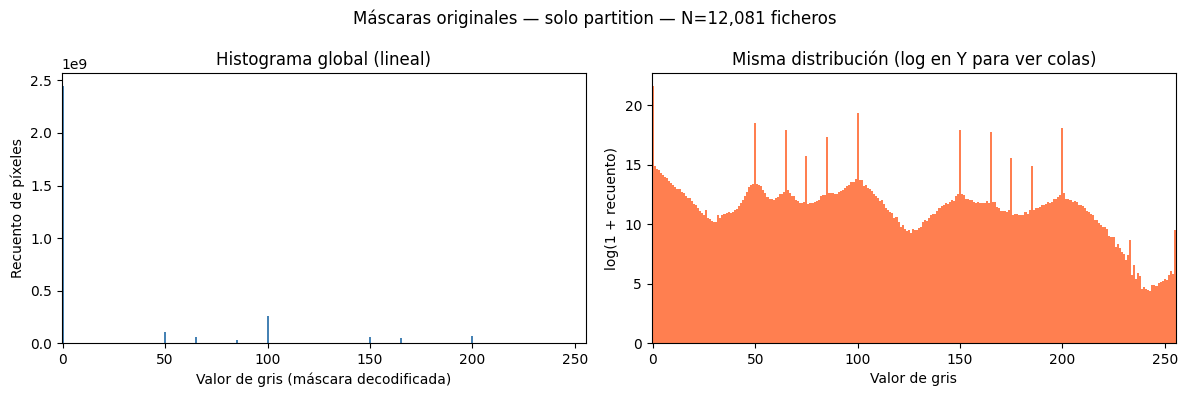

In [4]:
x = np.arange(256)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(x, hist, width=1.0, color="steelblue", edgecolor="none")
axes[0].set_xlabel("Valor de gris (máscara decodificada)")
axes[0].set_ylabel("Recuento de píxeles")
axes[0].set_title("Histograma global (lineal)")
axes[0].set_xlim(-0.5, 255.5)

axes[1].bar(x, np.log1p(hist), width=1.0, color="coral", edgecolor="none")
axes[1].set_xlabel("Valor de gris")
axes[1].set_ylabel("log(1 + recuento)")
axes[1].set_title("Misma distribución (log en Y para ver colas)")
axes[1].set_xlim(-0.5, 255.5)

mode = "todas en masks/" if USE_ALL_MASKS_IN_FOLDER else "solo partition"
fig.suptitle(f"Máscaras originales — {mode} — N={len(mask_paths):,} ficheros")
plt.tight_layout()
plt.show()